# Práctica Deep Learning para NLP: Similitud Semántica (STS)

## Introducción

El objetivo de esta práctica es construir un sistema capaz de estimar la **similitud semántica** entre pares de frases, es decir, determinar en qué medida dos frases expresan el mismo significado. Se trata de un problema de **regresión**, donde la salida del modelo es un valor continuo entre 0 y 5: el extremo inferior (0) indica que las frases no tienen ninguna relación semántica, mientras que el extremo superior (5) indica que son prácticamente idénticas en significado.

Para ello se utiliza el dataset [**STS Benchmark**](https://huggingface.co/datasets/mteb/stsbenchmark-sts) (Semantic Textual Similarity Benchmark), un benchmark ampliamente utilizado en NLP que contiene pares de frases anotadas manualmente con su score de similitud. El dataset está dividido en tres conjuntos: entrenamiento (5.700 pares), validación (1.500 pares) y test (1.400 pares). La métrica de evaluación empleada es la **correlación de Pearson** entre los scores predichos por el modelo y los scores reales, que mide la relación lineal entre ambas variables.

## Framework experimental

Para abordar el problema se plantea una comparativa sistemática de modelos, donde cada experimento cambia exactamente una variable respecto al anterior, permitiendo aislar el efecto de cada decisión de diseño. Las variables experimentales consideradas son las siguientes:

- **Arquitectura**: se comparan dos aproximaciones fundamentales. El **cross-encoder** procesa el par de frases de forma conjunta, permitiendo que el modelo capture interacciones directas entre ambas frases a través del mecanismo de atención. El **bi-encoder** codifica cada frase de forma independiente y calcula la similitud mediante la distancia coseno entre los embeddings resultantes.

- **Estrategia de fine-tuning**: se comparan dos métodos de adaptación del modelo pre-entrenado. El **fine-tuning con capas congeladas** libera únicamente las capas superiores del encoder, mientras que **LoRA** (Low-Rank Adaptation) mantiene todos los pesos originales congelados e incorpora matrices de bajo rango entrenables en las capas de atención, reduciendo drásticamente el número de parámetros a actualizar.

- **Modelo pre-entrenado**: se evalúan dos modelos pree-entrenados con características muy distintas. `roberta-base` es un modelo de propósito general, mientras que `all-MiniLM-L6-v2` es un modelo específicamente entrenado para tareas de similitud semántica con más de mil millones de pares de frases.

## Imports y configuración

In [ ]:
!pip install pytorch-lightning==2.1.0 torchmetrics==1.2.0 transformers==4.48.1 datasets==2.14.6 tqdm sentence-transformers==3.4.0 --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 774.6/774.6 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 805.2/805.2 kB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 86.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 493.7/493.7 kB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.4/166.4 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 96.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 13.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behavi

In [ ]:
!pip install peft -q

In [ ]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as pl
import os
import glob
import seaborn as sns
from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset
from torchmetrics import PearsonCorrCoef
from sentence_transformers import SentenceTransformer
from scipy.stats import pearsonr
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
from pytorch_lightning.loggers import CSVLogger
from peft import get_peft_model, LoraConfig, TaskType
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

In [ ]:
import logging
logging.getLogger('pytorch_lightning').setLevel(logging.WARNING)

In [ ]:
# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando dispositivo: {device}')

Usando dispositivo: cuda


In [ ]:
FOLDER_PATH = "/content/drive/MyDrive/Master/10. Deep Learning para NLP/00. Proyecto - NLP/Checkpoints"

# Create the folder if it does not exist
if not os.path.exists(FOLDER_PATH):
    os.makedirs(FOLDER_PATH)
    print(f"Folder '{FOLDER_PATH}' created.")
else:
    print(f"Folder '{FOLDER_PATH}' already exists.")

Folder '/content/drive/MyDrive/Master/10. Deep Learning para NLP/00. Proyecto - NLP/Checkpoints' already exists.


In [ ]:
# Definimos los directorios base para cada experimento
EXP_DIRS = {
    '1_crossencoder':  f'{FOLDER_PATH}/1_Crossencoder',
    '2_biencoder':     f'{FOLDER_PATH}/2_Biencoder',
    '3_biencoder_minilm':     f'{FOLDER_PATH}/3_Biencoder_minilm',
    '4_lora':     f'{FOLDER_PATH}/4_lora',
    '5_lora_minilm':     f'{FOLDER_PATH}/5_lora_minilm',

}

for name, path in EXP_DIRS.items():
    os.makedirs(f'{path}', exist_ok=True)
    os.makedirs(f'{path}/logs', exist_ok=True)
    print(f'{path}/')

/content/drive/MyDrive/Master/10. Deep Learning para NLP/00. Proyecto - NLP/Checkpoints/1_Crossencoder/
/content/drive/MyDrive/Master/10. Deep Learning para NLP/00. Proyecto - NLP/Checkpoints/2_Biencoder/
/content/drive/MyDrive/Master/10. Deep Learning para NLP/00. Proyecto - NLP/Checkpoints/3_Biencoder_minilm/
/content/drive/MyDrive/Master/10. Deep Learning para NLP/00. Proyecto - NLP/Checkpoints/4_lora/
/content/drive/MyDrive/Master/10. Deep Learning para NLP/00. Proyecto - NLP/Checkpoints/5_lora_minilm/


## Carga y exploración del dataset

El dataset empleado es el **STS Benchmark**, disponible en Hugging Face bajo el identificador `mteb/stsbenchmark-sts`. Contiene pares de frases extraídas de diversas fuentes (noticias, foros, subtítulos) anotadas manualmente con un score de similitud semántica entre 0 y 5. Está dividido en tres conjuntos:

| Split | Ejemplos |
|---|---|
| Train | 5.749 |
| Validation | 1.500 |
| Test | 1.379 |

Cada ejemplo contiene las columnas `sentence1`, `sentence2` y `score`, que son las únicas relevantes para la tarea. El resto de columnas (`split`, `genre`, `dataset`, `year`, `sid`) son metadatos de procedencia que no se utilizan durante el entrenamiento.

In [ ]:
dataset = load_dataset("mteb/stsbenchmark-sts")
display(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Extracting data files:   0%|          | 0/3 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['split', 'genre', 'dataset', 'year', 'sid', 'score', 'sentence1', 'sentence2'],
        num_rows: 5749
    })
    validation: Dataset({
        features: ['split', 'genre', 'dataset', 'year', 'sid', 'score', 'sentence1', 'sentence2'],
        num_rows: 1500
    })
    test: Dataset({
        features: ['split', 'genre', 'dataset', 'year', 'sid', 'score', 'sentence1', 'sentence2'],
        num_rows: 1379
    })
})

A modo de ejemplo, los primeros registros del conjunto de entrenamiento ilustran bien la escala de similitud.

In [ ]:
# Inspeccionamos algunos ejemplos del split de entrenamiento
print('Columnas disponibles:', dataset['train'].column_names)
print()
for i in range(3):
    ex = dataset['train'][i]
    print(f"Frase 1: {ex['sentence1']}")
    print(f"Frase 2: {ex['sentence2']}")
    print(f"Score:   {ex['score']}")
    print()

Columnas disponibles: ['split', 'genre', 'dataset', 'year', 'sid', 'score', 'sentence1', 'sentence2']

Frase 1: A plane is taking off.
Frase 2: An air plane is taking off.
Score:   5.0

Frase 1: A man is playing a large flute.
Frase 2: A man is playing a flute.
Score:   3.8

Frase 1: A man is spreading shreded cheese on a pizza.
Frase 2: A man is spreading shredded cheese on an uncooked pizza.
Score:   3.8



### Distribución de la variable objetivo

El score medio del conjunto de entrenamiento es **2.70**, con una desviación típica de 1.46, lo que indica que los ejemplos están distribuidos a lo largo de toda la escala sin una concentración excesiva en ningún extremo.

El histograma muestra dos zonas de mayor densidad: una en torno a 0 (pares sin relación semántica) y otra entre 3 y 5 (pares con similitud moderada-alta), con un valle relativo en los valores intermedios. La mediana se sitúa en 3, ligeramente por encima de la media, lo que sugiere una distribución con cierto sesgo hacia los scores más altos.

Esta distribución es relevante porque el modelo deberá aprender a discriminar tanto en los extremos como en la zona intermedia, donde la frontera entre niveles de similitud es más difusa.

Ejemplos — Train: 5749 | Val: 1500 | Test: 1379


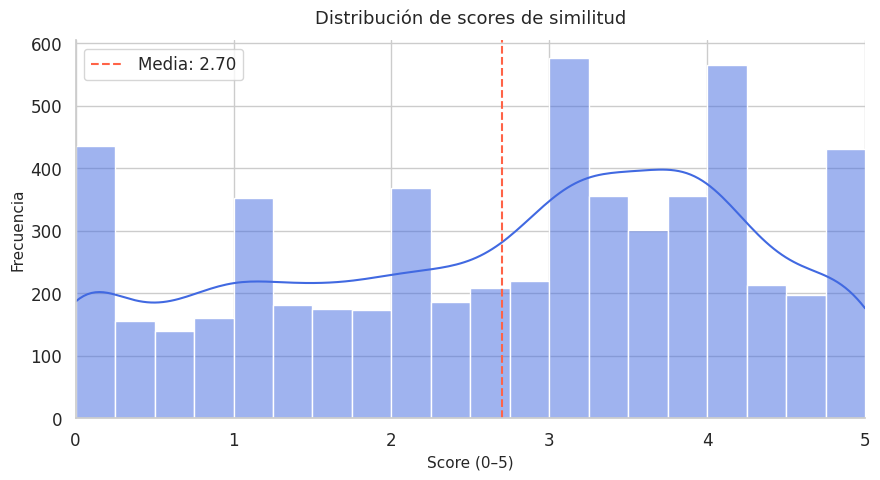

In [ ]:
print(f"Ejemplos — Train: {len(dataset['train'])} | Val: {len(dataset['validation'])} | Test: {len(dataset['test'])}")

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
df_train = dataset["train"].to_pandas()

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot( data=df_train, x="score", bins=20, kde=True, color="royalblue", ax=ax)

mean_val = df_train["score"].mean()
ax.axvline(mean_val, color="tomato", linewidth=1.5, linestyle="--", label=f"Media: {mean_val:.2f}")

ax.set_title("Distribución de scores de similitud", fontsize=13, pad=12)
ax.set_xlabel("Score (0–5)", fontsize=11)
ax.set_ylabel("Frecuencia", fontsize=11)
ax.set_xlim(0, 5)
ax.legend()

sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
df_train["score"].describe()

,score
count,5749.000000
mean,2.700999
std,1.464398
min,0.000000
25%,1.500000
50%,3.000000
75%,3.800000
max,5.000000


## Funciones generales

Se definen una serie de funciones y clases auxiliares que son reutilizadas por todos los experimentos.

**`freeze_layers_for_bert_based_models(model, num_frozen_layers)`**: congela los primeros `num_frozen_layers` bloques del encoder junto con la capa de embeddings, estableciendo `requires_grad=False` en sus parámetros. Las capas no congeladas se actualizarán durante el entrenamiento.

In [ ]:
# Función de congelado de capas
def freeze_layers_for_bert_based_models(model, num_frozen_layers):
    """Congela las primeras num_frozen_layers capas del encoder y los embeddings."""
    for layer in model.encoder.layer[:num_frozen_layers]:
        for param in layer.parameters():
            param.requires_grad = False
    for param in model.embeddings.parameters():
        param.requires_grad = False

**`normalize_score(score)` / `denormalize_score(score)`**: convierten el score entre la escala original [0, 5] y la escala normalizada [0, 1] que utiliza la función de pérdida durante el entrenamiento. La predicción final se desnormaliza antes de reportarse.

In [ ]:
# Normalización de scores a [0, 1] para la MSELoss
SCORE_MIN, SCORE_MAX = 0.0, 5.0
def normalize_score(score):
    return (score - SCORE_MIN) / (SCORE_MAX - SCORE_MIN)

def denormalize_score(score):
    return score * (SCORE_MAX - SCORE_MIN) + SCORE_MIN

**`compute_pearson(predictions, labels)`**: calcula la correlación de Pearson entre las predicciones del modelo y los scores reales. Es la métrica principal de evaluación de la práctica.

In [ ]:
# Evaluación con correlación de Pearson
def compute_pearson(predictions, labels):
    """Calcula la correlación de Pearson entre predicciones y etiquetas reales."""
    corr, _ = pearsonr(predictions, labels)
    return corr

**`plot_training_history(log_dir, title)`**: lee el fichero `metrics.csv` generado por el `CSVLogger` de PyTorch Lightning y representa las curvas de loss (MSE) y correlación de Pearson para los conjuntos de train y validación a lo largo de las épocas.

In [ ]:
def plot_training_history(log_dir, title=''):
    """
    Lee el metrics.csv generado por CSVLogger y plotea loss y Pearson
    por época, separando train y val.
    """
    csv_path = f'{log_dir}/metrics.csv'
    df = pd.read_csv(csv_path)

    # Separamos columnas de train y val, agrupando por época
    train_cols = [c for c in df.columns if c.startswith('train_')]
    val_cols   = [c for c in df.columns if c.startswith('val_')]

    # Cada métrica tiene NaN en los pasos donde no se loguea
    # Agrupamos por época tomando el último valor no-nulo de cada grupo
    df_train = (
        df[['epoch'] + train_cols]
        .dropna(subset=train_cols, how='all')
        .groupby('epoch', as_index=False)
        .last()
    )
    df_val = (
        df[['epoch'] + val_cols]
        .dropna(subset=val_cols, how='all')
        .groupby('epoch', as_index=False)
        .last()
    )

    epochs_train = df_train['epoch'].values
    epochs_val   = df_val['epoch'].values

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Loss
    if 'train_loss' in df_train.columns:
        axes[0].plot(epochs_train, df_train['train_loss'],
                     label='Train', color='royalblue', marker='o', markersize=4)
    if 'val_loss' in df_val.columns:
        axes[0].plot(epochs_val, df_val['val_loss'],
                     label='Val', color='tomato', marker='o', markersize=4)
    axes[0].set_title('Loss (MSE)')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Pearson
    if 'train_pearson' in df_train.columns:
        axes[1].plot(epochs_train, df_train['train_pearson'],
                     label='Train', color='royalblue', marker='o', markersize=4)
    if 'val_pearson' in df_val.columns:
        axes[1].plot(epochs_val, df_val['val_pearson'],
                     label='Val', color='tomato', marker='o', markersize=4)
    axes[1].set_title('Correlación de Pearson')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Pearson')
    axes[1].set_ylim(0, 1)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Experimento 0: Baseline

Como punto de referencia se utiliza el modelo `sentence-transformers /all-MiniLM-L6-v2` aplicado directamente sobre los pares de frases, sin ningún tipo de entrenamiento adicional.

`all-MiniLM-L6-v2` es un modelo específicamente diseñado para tareas de similitud semántica. A diferencia de modelos de propósito general como `bert-base` o `roberta-base`, este modelo fue entrenado con más de mil millones de pares de frases con el objetivo explícito de que la distancia coseno entre sus embeddings refleje similitud semántica real. Es por tanto el candidato natural para un baseline: representa el mejor resultado que se puede obtener sin realizar ningún entrenamiento propio.

Al no aplicar ningún ajuste sobre el dataset STS Benchmark, el modelo no ha visto ninguno de los ejemplos de entrenamiento. Esto lo convierte en una referencia honesta que responde a la pregunta: ¿cuánto aporta realmente el fine-tuning? Cualquier modelo entrenado que no supere este resultado estaría añadiendo complejidad sin beneficio real.

In [ ]:
# Cargamos el modelo pre-entrenado de sentence-transformers
baseline_model = SentenceTransformer(
    'sentence-transformers/all-MiniLM-L6-v2',
    device=device,
)
print('Modelo baseline cargado.')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Modelo baseline cargado.


La similitud coseno devuelve valores en el rango [-1, 1], mientras que los scores del dataset están en [0, 5]. Para poder comparar las predicciones con las etiquetas reales se aplica la siguiente transformación:

$$\text{score} = \frac{(\text{cos_sim} + 1)}{2} \times 5$$

Es importante remarcar que esta transformación es **puramente mecánica**: asume que la relación entre la similitud coseno y el score real es lineal y perfecta, lo cual no tiene por qué ser cierto.

In [ ]:
def evaluate_biencoder(model, split, batch_size=64):
    """
    Evalúa un modelo bi-encoder en un split del dataset.
    Devuelve predicciones, etiquetas reales y la correlación de Pearson.
    """
    all_preds = []
    all_labels = []

    for i in tqdm(range(0, len(split), batch_size), desc='Evaluando baseline'):
        batch = split[i:i + batch_size]
        s1 = batch['sentence1']
        s2 = batch['sentence2']
        labels = batch['score']

        # Codificamos ambas frases
        emb1 = model.encode(s1, convert_to_tensor=True, show_progress_bar=False)
        emb2 = model.encode(s2, convert_to_tensor=True, show_progress_bar=False)

        # Similitud coseno → rango [-1, 1] → escalamos a [0, 5]
        cos_sim = F.cosine_similarity(emb1, emb2, dim=1)
        preds = ((cos_sim + 1) / 2) * 5  # Reescalamos a [0, 5]

        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels)

    pearson = compute_pearson(all_preds, all_labels)
    return all_preds, all_labels, pearson

_, _, baseline_pearson_val = evaluate_biencoder(baseline_model, dataset['validation'])
_, _, baseline_pearson_test = evaluate_biencoder(baseline_model, dataset['test'])
print(f'\n📊 Baseline — Pearson (val): {baseline_pearson_val:.4f}')
print(f'   Baseline — Pearson (test): {baseline_pearson_test:.4f}')

Evaluando baseline: 100%|██████████| 22/22 [00:01<00:00, 18.90it/s]


📊 Baseline — Pearson (val): 0.8696
   Baseline — Pearson (test): 0.8274


El modelo baseline obtiene una correlación de Pearson de **0.8274** en el conjunto de test, lo que representa un resultado sólido teniendo en cuenta que no se ha realizado ningún entrenamiento sobre el dataset. Esto confirma que `all-MiniLM-L6-v2` tiene un espacio de embeddings bien calibrado para la tarea de similitud semántica.

Se observa una diferencia de aproximadamente 0.04 puntos entre validación (0.8696) y test (0.8274), lo cual es esperable dado que no hay ningún proceso de optimización que pueda haber introducido sesgo hacia ninguno de los dos conjuntos.

Este resultado establece el **listón mínimo** que cualquier modelo entrenado debería superar para justificar el coste computacional del fine-tuning.

## Experimento 1: Cross-encoder con cabeza de regresión

Un **cross-encoder** recibe el par de frases concatenado como una única secuencia de entrada, separada por el token especial `[SEP]`. Esto permite que el mecanismo de atención del transformer procese las dos frases de forma conjunta, capturando interacciones directas entre sus tokens desde las primeras capas. Esta capacidad de comparación directa hace que el cross-encoder sea especialmente adecuado para tareas donde la relación entre dos textos es lo que se quiere modelar, como es el caso de la similitud semántica.

La arquitectura toma como base el modelo `roberta-base` y le añade una **cabeza de regresión** compuesta por una capa `Dropout` y una capa lineal `nn.Linear(hidden_size, 1)` que produce un único valor escalar. Este valor se pasa por una función `sigmoid` para acotarlo en el rango [0, 1], y posteriormente se desnormaliza a [0, 5] para obtener el score final.

Se decidió emplear `roberta-base` como modelo pre-entrenado en lugar de `bert-base` debido a que:

- **RoBERTa** fue entrenado con más datos y durante más tiempo que BERT, eliminando además el objetivo de Next Sentence Prediction (NSP), por lo que el modelo se centra en obtener representaciones contextuales de mayor calidad.

- BERT utiliza *sentence embeddings* (que actúan como `token_type_ids`) para distinguir entre los segmentos EA y EB en tareas de parejas de frases. En cambio, RoBERTa elimina esta necesidad y se limita a utilizar los tokens
especiales `<s>` y `</s>` para delimitar y separar las secuencias de texto, lo que simplifica la estructura de entrada sin perder la capacidad de procesar parejas.


Este experimento es una adaptación directa del ejercicio de NLI visto en clase. Los cambios respecto a esa implementación son mínimos pero fundamentales para convertir el problema de clasificación en regresión:

| Elemento | NLI (clase) | Exp. 1 (regresión) |
|---|---|---|
| Cabeza | `nn.Linear(hidden, 3)` | `nn.Linear(hidden, 1)` |
| Función de pérdida | `CrossEntropyLoss` | `MSELoss` |
| Métrica | `Accuracy` | `PearsonCorrCoef` |
| Labels | Clases discretas | Scores continuos normalizados [0, 1] |

El uso de `normalize_score` para llevar los labels de [0, 5] a [0, 1] es necesario para que la `MSELoss` compare predicciones y etiquetas en la misma escala. Sin esta normalización, el error sería mucho mayor, lo que desestabiliza el entrenamiento y dificulta que el modelo aprenda correctamente.

La implementación sigue el patrón visto en clase, basado en PyTorch Lightning, y se estructura en tres clases: `STSCollateFn`, `STSDataModule` y `STSRegressorCrossEncoder`

**`STSCollateFn`**

Se encarga de preparar cada batch para el cross-encoder. Recibe una lista
de ejemplos del dataset y devuelve la tokenización del par de frases concatenado junto con los labels normalizados a [0, 1].

In [ ]:
# Tokeniza pares de frases con sus scores
class STSCollateFn:
    def __init__(self, tokenizer_name, max_length):
        self.tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
        self.max_length = max_length

    def __call__(self, batch):
        s1 = [ex['sentence1'] for ex in batch]
        s2 = [ex['sentence2'] for ex in batch]
        scores = [normalize_score(ex['score']) for ex in batch]  # Normalizamos a [0,1]

        # Tokenizamos el par de frases
        encoded = self.tokenizer(
            list(zip(s1, s2)),
            max_length=self.max_length,
            padding=True,
            truncation=True,
            return_tensors='pt',
        )

        labels = torch.tensor(scores, dtype=torch.float32)
        return encoded, labels

**`STSDataModule`**

Gestiona la carga y organización del dataset. Se encarga de instanciar
los tres splits (train, validation y test) y proporcionar los DataLoaders correspondientes, usando `STSCollateFn` para procesar cada batch.

In [ ]:
# DataModule
class STSDataModule(pl.LightningDataModule):
    def __init__(self, tokenizer_name, max_length=128, batch_size=32):
        super().__init__()
        self.tokenizer_name = tokenizer_name
        self.max_length = max_length
        self.batch_size = batch_size

    def setup(self, stage=None):
        ds = load_dataset('mteb/stsbenchmark-sts')
        self.train = ds['train']
        self.val   = ds['validation']
        self.test  = ds['test']

    def _dataloader(self, split, shuffle=False):
        return torch.utils.data.DataLoader(
            split,
            batch_size=self.batch_size,
            shuffle=shuffle,
            collate_fn=STSCollateFn(self.tokenizer_name, self.max_length),
            num_workers=2,
        )

    def train_dataloader(self): return self._dataloader(self.train, shuffle=True)
    def val_dataloader(self):   return self._dataloader(self.val)
    def test_dataloader(self):  return self._dataloader(self.test)

**`STSRegressorCrossEncoder`**

Contiene el modelo completo. Recibe los tokens del par de
frases, los pasa por `roberta-base`, aplica mean pooling sobre el `last_hidden_state` y produce un score de similitud mediante la cabeza de regresión. Durante el entrenamiento calcula la `MSELoss` y la correlación de Pearson, que se registran para train y validación en cada época.

In [ ]:
# Modelo: RoBERTa + MLP cabeza de regresión
class STSRegressorCrossEncoder(pl.LightningModule):
    """
    Cross-encoder para similitud semántica.
    Recibe el par de frases concatenado y predice un score continuo.
    """
    def __init__(self, model_name, optimizer_params, pooling='mean', frozen_layers=0):
        super().__init__()
        self.model = AutoModel.from_pretrained(model_name)
        self.regressor = nn.Linear(self.model.config.hidden_size, 1)  # Salida escalar
        freeze_layers_for_bert_based_models(self.model, frozen_layers)

        assert pooling in ['cls', 'mean']
        self.pooling = pooling
        self.optimizer_params = optimizer_params

        self.pearson = PearsonCorrCoef()
        self.loss_fn = nn.MSELoss()

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        outputs = self.model(
            input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        )
        last_hidden = outputs.last_hidden_state  # (B, L, H)

        if self.pooling == 'cls':
            pooled = last_hidden[:, 0, :]  # Token [CLS]
        else:
            # Mean pooling ignorando padding (igual que en clase)
            mask = attention_mask.float()
            mean_coeffs = mask / mask.sum(dim=1, keepdim=True)
            pooled = torch.einsum('bld,bl->bd', last_hidden, mean_coeffs)

        score = self.regressor(pooled).squeeze(-1)  # (B,)
        return torch.sigmoid(score)  # Salida en [0, 1] (luego desnormalizamos)

    def _step(self, batch):
        encoded, labels = batch
        preds = self(
            encoded['input_ids'],
            encoded['attention_mask'],
            encoded.get('token_type_ids'),
        )
        loss = self.loss_fn(preds, labels)
        pearson = self.pearson(preds, labels)
        return loss, pearson

    def training_step(self, batch, batch_idx):
        loss, pearson = self._step(batch)
        self.log('train_loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('train_pearson', pearson, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, pearson = self._step(batch)
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_pearson', pearson, prog_bar=True)

    def test_step(self, batch, batch_idx):
        loss, pearson = self._step(batch)
        self.log('test_loss', loss)
        self.log('test_pearson', pearson)

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), **self.optimizer_params)

Los hiperparámetros más relevantes para este experimento son:

- **`FROZEN_LAYERS = 6`**: se congelan las 6 primeras capas del encoder, dejando libres las 6  superiores. Esta decisión surge de una exploración previa con `frozen_layers=10`, que demostró que con solo 2 capas activas el modelo no tenía suficiente capacidad para adaptarse a la tarea, produciendo overfitting y resultados por debajo del baseline.

- **`POOLING = 'mean'`**: se utiliza mean pooling sobre el `last_hidden_state` en lugar de tomar únicamente el token `[CLS]`. Esta estrategia agrega la información de todos los tokens de la secuencia, obteniendo una representación más completa del par de frases.

- **`MAX_LENGTH = 128`**: limita la longitud máxima de la secuencia tokenizada. Se establece como un equilibrio entre eficiencia computacional y cobertura de la mayoría de los pares de frases del dataset STS Benchmark.

- **`lr = 2e-5`**: learning rate estándar para fine-tuning de modelos transformer, lo suficientemente pequeño para no destruir las representaciones pre-entrenadas durante el ajuste.

In [ ]:
# Hiperparámetros experimento 1
MODEL_EXP1    = 'FacebookAI/roberta-base'
MAX_LENGTH    = 128
BATCH_SIZE    = 32
POOLING       = 'mean'
FROZEN_LAYERS = 6   # Dejamos 6 capas activas de 12
OPTIMIZER_PARAMS = {'lr': 2e-5, 'weight_decay': 0.01}
MAX_EPOCHS    = 50

# DataModule
data_module_exp1 = STSDataModule(MODEL_EXP1, MAX_LENGTH, BATCH_SIZE)
# Modelo
model_exp1 = STSRegressorCrossEncoder(
    MODEL_EXP1, OPTIMIZER_PARAMS, POOLING, FROZEN_LAYERS
)

data_module_exp1.setup()
print(f'Parámetros entrenables: {sum(p.numel() for p in model_exp1.parameters() if p.requires_grad):,}')

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at FacebookAI/roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Parámetros entrenables: 43,118,593


In [ ]:
EXP_DIR = EXP_DIRS['1_crossencoder']

checkpoint_cb = ModelCheckpoint(
    dirpath=EXP_DIR,
    monitor='val_pearson',
    mode='max',
    save_top_k=1,
    filename='best-{epoch:02d}-{val_pearson:.4f}',
)
early_stop_cb = EarlyStopping(monitor='val_pearson', mode='max', patience=5)

logger_exp1 = CSVLogger(
    save_dir=f'{EXP_DIR}/logs',
    name = ''
)


trainer_exp1 = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator='gpu',
    devices=1,
    precision='16-mixed',
    callbacks=[checkpoint_cb, early_stop_cb],
    logger=logger_exp1,
)

trainer_exp1.fit(model_exp1, data_module_exp1)
exp1_val_pearson = checkpoint_cb.best_model_score.item()

print(f'\n✅ Checkpoint guardado en: {checkpoint_cb.best_model_path}')

INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/plugins/precision/amp.py:54: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:630: Checkpoint directory /content/drive/MyDrive/Master/10. Deep Learning para NLP/00. Proyecto - NLP/Checkpoints/1_Crossencoder exists and is not empty.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name      | T

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: The variance of predictions or target is close to zero. This can cause instability in Pearson correlationcoefficient, leading to wrong results. Consider re-scaling the input if possible or computing using alarger dtype (currently using torch.float32).
  warnings.warn(*args, **kwargs)  # noqa: B028


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]


✅ Checkpoint guardado en: /content/drive/MyDrive/Master/10. Deep Learning para NLP/00. Proyecto - NLP/Checkpoints/1_Crossencoder/best-epoch=05-val_pearson=0.8532.ckpt


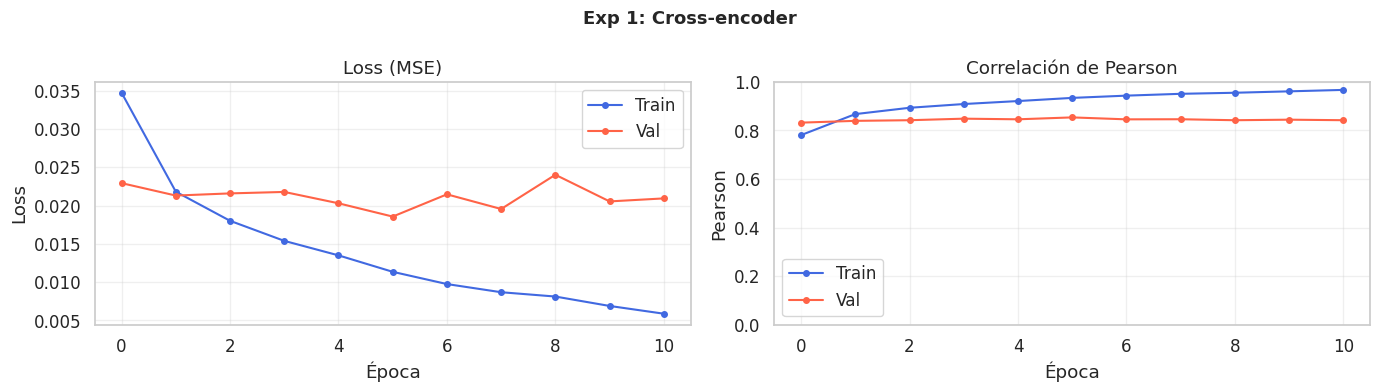

In [ ]:
plot_training_history(
    log_dir=f'{EXP_DIR}/logs/version_0',
    title='Exp 1: Cross-encoder'
)

El modelo obtiene una correlación de Pearson de **0.8575** en test, superando al baseline (0.8274). Esto confirma que el fine-tuning sobre el dataset STS aporta valor real frente a usar un modelo pre-entrenado directamente.

Las curvas de aprendizaje muestran un patrón claro de **overfitting**: el loss de train desciende de forma continua hasta valores muy bajos (~0.006), mientras que el loss de validación se estabiliza alrededor de 0.021 desde las primeras épocas. En el gráfico de Pearson se aprecia el mismo comportamiento: el modelo alcanza ~0.97 en train frente a ~0.83 en validación. El `EarlyStopping` detiene el entrenamiento en la época 10, guardando el checkpoint con mejor `val_pearson`.

A pesar del overfitting, el resultado en test (0.8575) es ligeramente superior al de validación (0.8532), lo que indica que el modelo generaliza correctamente y que el `EarlyStopping` ha cumplido su función de evitar que el sobreajuste se traduzca en pérdida de rendimiento real.

In [ ]:
# Evaluación en test
results_exp1 = trainer_exp1.test(ckpt_path='best', datamodule=data_module_exp1)
exp1_pearson_test = results_exp1[0]['test_pearson']

print(f'\n📊 Experimento 1 — Pearson (val): {exp1_val_pearson:.4f}')
print(f'   Experimento 1 — Pearson (test): {exp1_pearson_test:.4f}')

Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │    0.02260522171854973    │
│       test_pearson        │    0.8575302958488464     │
└───────────────────────────┴───────────────────────────┘


📊 Experimento 1 — Pearson (val): 0.8532
    Experimento 1 — Pearson (test): 0.8575


## Experimento 2: Bi-encoder fine-tuned

A diferencia del cross-encoder, un **bi-encoder** codifica cada frase de forma
**independiente**, generando un embedding para cada una de ellas. La similitud entre el par se calcula posteriormente mediante la **similitud coseno** entre ambos embeddings, sin que el modelo haya podido observar las dos frases de forma conjunta en ningún momento.

Esta arquitectura sigue el esquema propuesto en el paper **Sentence-BERT (SBERT)**, donde dos ramas comparten los mismos pesos del encoder y se entrenan para que el coseno entre los embeddings resultantes refleje la similitud semántica
real entre las frases.

Una diferencia fundamental respecto al experimento 1 es que el bi-encoder **no tiene cabeza de regresión**. El score de similitud emerge directamente de la geometría del espacio de embeddings: el modelo no aprende un mapeo explícito a un valor numérico, sino que aprende a posicionar los embeddings en el espacio vectorial de forma que frases similares queden cerca y frases distintas queden lejos.

La función de pérdida empleada es `MSELoss` sobre la similitud coseno reescalada a [0, 1]:

$$\text{pred} = \frac{(\text{cos_sim} + 1)}{2}$$

Al igual que en el experimento 1, los labels se normalizan a [0, 1] mediante `normalize_score` para que la comparación con las predicciones sea coherente. Sin esta normalización, la `MSELoss` estaría comparando valores en escalas distintas, distorsionando el gradiente.

La implementación introduce 3 nuevas clases respecto al experimento anterior, adaptadas para procesar cada frase del par de forma independiente: **`STSBiEncoderCollateFn`**, **`STSBiEncoderDataModule`**  y **`STSBiEncoder`**.

**`STSBiEncoderCollateFn`**

A diferencia de `STSCollateFn`, tokeniza cada frase por separado en lugar de concatenarlas. Recibe una lista de ejemplos y devuelve dos tokenizaciones independientes (`enc1`, `enc2`) junto con los labels normalizados a [0, 1].

In [ ]:
# CollateFn para Bi-encoder, procesa cada frase por separado
class STSBiEncoderCollateFn:
    """Tokeniza cada frase del par de forma independiente."""
    def __init__(self, tokenizer_name, max_length):
        self.tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
        self.max_length = max_length

    def _encode(self, texts):
        return self.tokenizer(
            texts,
            max_length=self.max_length,
            padding=True,
            truncation=True,
            return_tensors='pt',
        )

    def __call__(self, batch):
        s1 = [ex['sentence1'] for ex in batch]
        s2 = [ex['sentence2'] for ex in batch]
        # Normalizamos scores a [0, 1]
        scores = [normalize_score(ex['score']) for ex in batch]

        enc1 = self._encode(s1)
        enc2 = self._encode(s2)
        labels = torch.tensor(scores, dtype=torch.float32)
        return enc1, enc2, labels

**`STSBiEncoderDataModule`**

Equivalente al `STSDataModule` del experimento 1 pero usando `STSBiEncoderCollateFn` como función de collate. Gestiona los tres splits del dataset y proporciona los DataLoaders correspondientes.

In [ ]:
# DataModule para Bi-encoder
class STSBiEncoderDataModule(pl.LightningDataModule):
    def __init__(self, tokenizer_name, max_length=128, batch_size=32):
        super().__init__()
        self.tokenizer_name = tokenizer_name
        self.max_length = max_length
        self.batch_size = batch_size

    def setup(self, stage=None):
        ds = load_dataset('mteb/stsbenchmark-sts')
        self.train = ds['train']
        self.val   = ds['validation']
        self.test  = ds['test']

    def _dataloader(self, split, shuffle=False):
        return torch.utils.data.DataLoader(
            split,
            batch_size=self.batch_size,
            shuffle=shuffle,
            collate_fn=STSBiEncoderCollateFn(self.tokenizer_name, self.max_length),
            num_workers=2,
        )

    def train_dataloader(self): return self._dataloader(self.train, shuffle=True)
    def val_dataloader(self):   return self._dataloader(self.val)
    def test_dataloader(self):  return self._dataloader(self.test)

**`STSBiEncoder`**

Contiene el modelo completo. A diferencia de `STSRegressorCrossEncoder`, no tiene cabeza de regresión. Expone un método `encode` que recibe la tokenización de una frase y devuelve su embedding mediante mean pooling. El método `forward` llama a `encode` para cada frase del par y devuelve ambos embeddings, a partir de los cuales se calcula la similitud coseno y la pérdida durante el entrenamiento.

In [ ]:
# Modelo Bi-encoder
class STSBiEncoder(pl.LightningModule):
    """
    Bi-encoder para similitud semántica.
    Codifica cada frase de forma independiente y entrena con MSELoss.
    Los pesos del encoder son compartidos entre ambas ramas.
    """
    def __init__(self, model_name, optimizer_params, pooling='mean', frozen_layers=0):
        super().__init__()
        self.model = AutoModel.from_pretrained(model_name)
        freeze_layers_for_bert_based_models(self.model, frozen_layers)

        assert pooling in ['cls', 'mean']
        self.pooling = pooling
        self.optimizer_params = optimizer_params
        self.loss_fn = nn.MSELoss()
        self.pearson = PearsonCorrCoef()

    def encode(self, input_ids, attention_mask, token_type_ids=None):
        """Codifica una frase a un vector de embedding."""
        outputs = self.model(
            input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        )
        last_hidden = outputs.last_hidden_state

        if self.pooling == 'cls':
            return last_hidden[:, 0, :]
        else:
            mask = attention_mask.float()
            mean_coeffs = mask / mask.sum(dim=1, keepdim=True)
            return torch.einsum('bld,bl->bd', last_hidden, mean_coeffs)

    def forward(self, enc1, enc2):
        emb1 = self.encode(enc1['input_ids'], enc1['attention_mask'], enc1.get('token_type_ids'))
        emb2 = self.encode(enc2['input_ids'], enc2['attention_mask'], enc2.get('token_type_ids'))
        return emb1, emb2

    def _step(self, batch):
        enc1, enc2, labels = batch
        emb1, emb2 = self(enc1, enc2)

        # Para Pearson: calculamos similitud coseno y la comparamos con el score original
        cos_sim = F.cosine_similarity(emb1, emb2)
        preds = (cos_sim + 1) / 2
        loss = self.loss_fn(preds, labels)
        pearson = self.pearson(preds, labels)
        return loss, pearson

    def training_step(self, batch, batch_idx):
        loss, pearson = self._step(batch)
        self.log('train_loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('train_pearson', pearson, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, pearson = self._step(batch)
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_pearson', pearson, prog_bar=True)

    def test_step(self, batch, batch_idx):
        loss, pearson = self._step(batch)
        self.log('test_loss', loss)
        self.log('test_pearson', pearson)

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), **self.optimizer_params)

La configuración es idéntica al experimento anterior, lo que permite aislar el efecto de la arquitectura como única variable de cambio entre ambos experimentos.

In [ ]:
# Hiperparámetros experimento 2
MODEL_EXP2 = 'FacebookAI/roberta-base'
MAX_LENGTH    = 128
BATCH_SIZE    = 32
POOLING       = 'mean'
FROZEN_LAYERS = 6   # Dejamos 6 capas activas de 12
OPTIMIZER_PARAMS = {'lr': 2e-5, 'weight_decay': 0.01}
MAX_EPOCHS    = 50

data_module_exp2 = STSBiEncoderDataModule(MODEL_EXP2, MAX_LENGTH, BATCH_SIZE)
model_exp2 = STSBiEncoder(
    MODEL_EXP2,
    OPTIMIZER_PARAMS,
    pooling=POOLING,
    frozen_layers=FROZEN_LAYERS,
)

data_module_exp2.setup()
print(f'Parámetros entrenables: {sum(p.numel() for p in model_exp2.parameters() if p.requires_grad):,}')

Some weights of RobertaModel were not initialized from the model checkpoint at FacebookAI/roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Parámetros entrenables: 43,117,824


In [ ]:
# Entrenamiento experimento 2
EXP2_DIR = EXP_DIRS['2_biencoder']

checkpoint_cb2 = ModelCheckpoint(
    dirpath=f'{EXP2_DIR}',
    monitor='val_pearson',
    mode='max',
    save_top_k=1,
    filename='best-{epoch:02d}-{val_pearson:.4f}',
)
early_stop_cb2 = EarlyStopping(monitor='val_pearson', mode='max', patience=2)

logger_exp2 = CSVLogger(
    save_dir=f'{EXP2_DIR}/logs',
    name=''
)

trainer_exp2 = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator='gpu',
    devices=1,
    precision='16-mixed',
    callbacks=[checkpoint_cb2, early_stop_cb2],
    logger=logger_exp2,
)

trainer_exp2.fit(model_exp2, data_module_exp2)
exp2_val_pearson = checkpoint_cb2.best_model_score.item()

print(f'\nCheckpoint guardado en: {checkpoint_cb2.best_model_path}')
print(f'Logs guardados en:       {EXP2_DIR}/logs/')

INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/plugins/precision/amp.py:54: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name    | Type            | Params
--------------------------------------------
0 | model   | RobertaModel    | 124 M 
1 | loss_fn | MSELoss         | 0     
2 | pearson | PearsonCorrCoef | 0     
--------------------------------------------
43.1 M    Tra

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: The variance of predictions or target is close to zero. This can cause instability in Pearson correlationcoefficient, leading to wrong results. Consider re-scaling the input if possible or computing using alarger dtype (currently using torch.float32).
  warnings.warn(*args, **kwargs)  # noqa: B028


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]


Checkpoint guardado en: /content/drive/MyDrive/Master/10. Deep Learning para NLP/00. Proyecto - NLP/Checkpoints/2_Biencoder/checkpoints/best-epoch=01-val_pearson=0.7154.ckpt
Logs guardados en:       /content/drive/MyDrive/Master/10. Deep Learning para NLP/00. Proyecto - NLP/Checkpoints/2_Biencoder/logs/


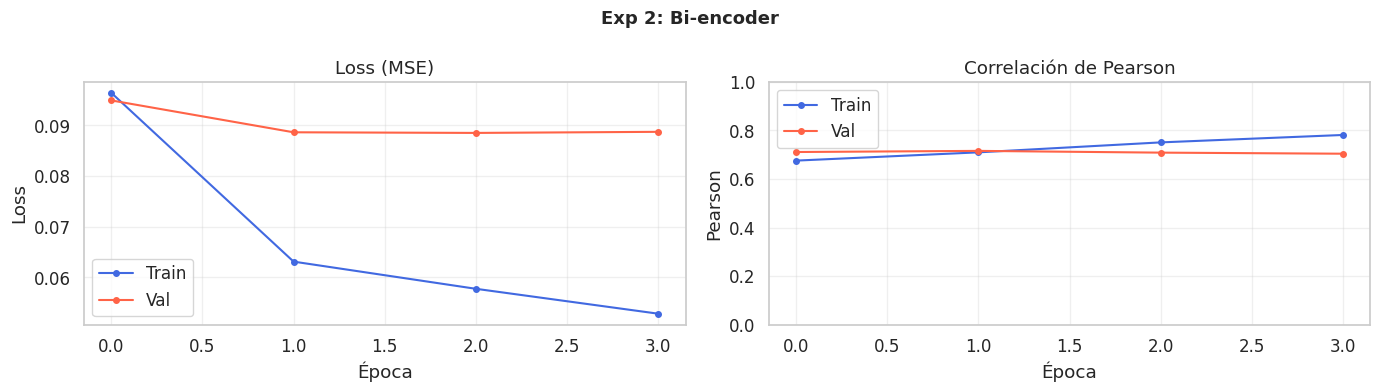

In [ ]:
plot_training_history(
    log_dir=f'{EXP2_DIR}/logs/version_0',
    title='Exp 2: Bi-encoder'
)

El modelo obtiene una correlación de Pearson de **0.6923** en test, resultado que queda por debajo tanto del experimento 1 (0.8575) como del baseline (0.8274).

Las curvas de aprendizaje revelan el problema principal: la loss de validación se estanca en torno a 0.089 desde la primera época, mientras que la loss de train sigue descendiendo. El Pearson de validación apenas mejora a lo largo del entrenamiento, manteniéndose entre 0.65 y 0.69. El `EarlyStopping` detiene el entrenamiento en la época 3 al no observar mejora en `val_pearson`.

El bi-encoder codifica cada frase de forma independiente, por lo que el modelo nunca puede observar la interacción directa entre ambas frases durante el entrenamiento. Esto hace que la señal de aprendizaje sea más débil que en el cross-encoder, que sí puede capturar dependencias cruzadas entre tokens de
ambas frases a través del mecanismo de atención.

A esto se añade que `roberta-base` es un modelo de propósito general, cuyo espacio de embeddings no está optimizado para similitud semántica. Con únicamente 5.749 ejemplos de entrenamiento, el modelo no dispone de suficiente información para adaptar ese espacio a la tarea. El baseline en cambio parte de un modelo entrenado específicamente para similitud semántica con más de mil millones de pares, lo que explica la diferencia de rendimiento a pesar de no haber realizado ningún entrenamiento adicional.

In [ ]:
# Evaluación en test
results_exp2 = trainer_exp2.test(ckpt_path='best', datamodule=data_module_exp2)
exp2_pearson_test = results_exp2[0]['test_pearson']

print(f'\n📊 Experimento 2 — Pearson (val): {exp2_val_pearson:.4f}')
print(f'    Experimento 2 — Pearson (test): {exp2_pearson_test:.4f}')

Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │    0.08316853642463684    │
│       test_pearson        │    0.6922937035560608     │
└───────────────────────────┴───────────────────────────┘


📊 Experimento 2 — Pearson (val): 0.7154
    Experimento 2 — Pearson (test): 0.6923


## Eperimento 3: Bi-encoder fine-tuned (all-MiniLM-L6-v2)

Este experimento es idéntico al experimento anterior en arquitectura, función de pérdida y estrategia de entrenamiento. La única variable que cambia es el **modelo pre-entrenado**, que pasa de `roberta-base` a `sentence-transformers/all-MiniLM-L6-v2`. El objetivo es aislar el efecto del modelo pre-entrenado y determinar si puede el fine-tuning sobre un modelo ya especializado en similitud semántica mejorar aún más su rendimiento.

`all-MiniLM-L6-v2` es el mismo modelo empleado en el baseline, con la diferencia de que aquí sí se realiza fine-tuning sobre el dataset STS Benchmark. Es un modelo más pequeño que `roberta-base` pero específicamente entrenado para tareas de similitud semántica con más de mil millones de pares de frases, lo que le otorga un espacio de embeddings mucho mejor calibrado para esta tarea desde el punto de partida.

Todos los hiperparametros se mantienen igual respecto al experimento anterior excepto uno.

- **`FROZEN_LAYERS = 5`**: como el modelo ya está especializado en STS, se congelan casi todas las capas y solo se entrena la última. Esto se basa en una prueba previa con fine-tuning completo (`frozen_layers=0`), que hizo que el modelo perdiera parte del conocimiento aprendido previamente al entrenarse con pocos datos (Pearson de 0.72 en test). Al congelar 5 de las 6 capas, se limitan los cambios a la parte más específica de la tarea y se preservan las representaciones pre-entrenadas.


In [ ]:
# Hiperparámetros experimento 3
MODEL_EXP3 = 'sentence-transformers/all-MiniLM-L6-v2'

# all-MiniLM-L6-v2 solo tiene 6 capas (vs 12 de roberta-base)
FROZEN_LAYERS_EXP3 = 5

# Learning rate más pequeño para evitar catastrophic forgetting
# El modelo ya tiene buenas representaciones, no queremos destruirlas
OPTIMIZER_PARAMS_EXP3 = {'lr': 2e-5, 'weight_decay': 0.01}

data_module_exp3 = STSBiEncoderDataModule(MODEL_EXP3, MAX_LENGTH, BATCH_SIZE)
model_exp3 = STSBiEncoder(
    MODEL_EXP3,
    OPTIMIZER_PARAMS_EXP3,
    pooling='mean',
    frozen_layers=FROZEN_LAYERS_EXP3,
)

data_module_exp3.setup()
print(f'Parámetros entrenables: {sum(p.numel() for p in model_exp3.parameters() if p.requires_grad):,}')

Parámetros entrenables: 1,922,304


In [ ]:
# Entrenamiento experimento 3
EXP3_DIR = EXP_DIRS['3_biencoder_minilm']

checkpoint_cb3 = ModelCheckpoint(
    dirpath=f'{EXP3_DIR}',
    monitor='val_pearson',
    mode='max',
    save_top_k=1,
    filename='best-{epoch:02d}-{val_pearson:.4f}',
)

early_stop_cb3 = EarlyStopping(monitor='val_pearson', mode='max', patience=5)

logger_exp3 = CSVLogger(
    save_dir=f'{EXP3_DIR}/logs',
    name='',
)

trainer_exp3 = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator='gpu',
    devices=1,
    precision='16-mixed',
    callbacks=[checkpoint_cb3, early_stop_cb3],
    logger=logger_exp3,
)

trainer_exp3.fit(model_exp3, data_module_exp3)
exp3_val_pearson = checkpoint_cb3.best_model_score.item()
print(f'✅ Checkpoint guardado en: {checkpoint_cb3.best_model_path}')
print(f'✅ Logs guardados en:       {EXP3_DIR}/logs/')

INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/plugins/precision/amp.py:54: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name    | Type            | Params
--------------------------------------------
0 | model   | BertModel       | 22.7 M
1 | loss_fn | MSELoss         | 0     
2 | pearson | PearsonCorrCoef | 0     
--------------------------------------------
1.9 M     Tra

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

✅ Checkpoint guardado en: /content/drive/MyDrive/Master/10. Deep Learning para NLP/00. Proyecto - NLP/Checkpoints/3_Biencoder_minilm/checkpoints/best-epoch=00-val_pearson=0.8262.ckpt
✅ Logs guardados en:       /content/drive/MyDrive/Master/10. Deep Learning para NLP/00. Proyecto - NLP/Checkpoints/3_Biencoder_minilm/logs/


El modelo obtiene una correlación de Pearson de **0.8031** en test, mejorando notablemente respecto al experimento 2 (0.6923) pero sin llegar a superar al baseline (0.8274).

Las curvas de aprendizaje muestran un comportamiento diferente al de los experimentos anteriores. El Pearson de train y validación se mantienen prácticamente paralelos y estables a lo largo de todas las épocas, en torno a 0.82, sin que se observe una mejora significativa. El loss de train desciende de forma continua mientras que la de validación se estanca, lo que indica que el modelo está aprendiendo a ajustarse al conjunto de entrenamiento sin conseguir transferir esa mejora a validación.

Este resultado confirma la hipótesis planteada antes del experimento: con solo 5.749 ejemplos de entrenamiento, el fine-tuning no aporta información suficiente para mejorar un modelo que ya fue entrenado específicamente para similitud semántica con más de mil millones de pares. Cualquier actualización de pesos introduce más ruido que señal, y el modelo no consigue superar su propio punto de partida sin fine-tuning.

La mejora respecto al experimento 2 se explica íntegramente por el cambio de modelo pre-entrenado: pasar de `roberta-base` (propósito general) a `all-MiniLM-L6-v2` (especializado en STS) supone una ganancia de 0.11 unidades, independientemente del fine-tuning aplicado.

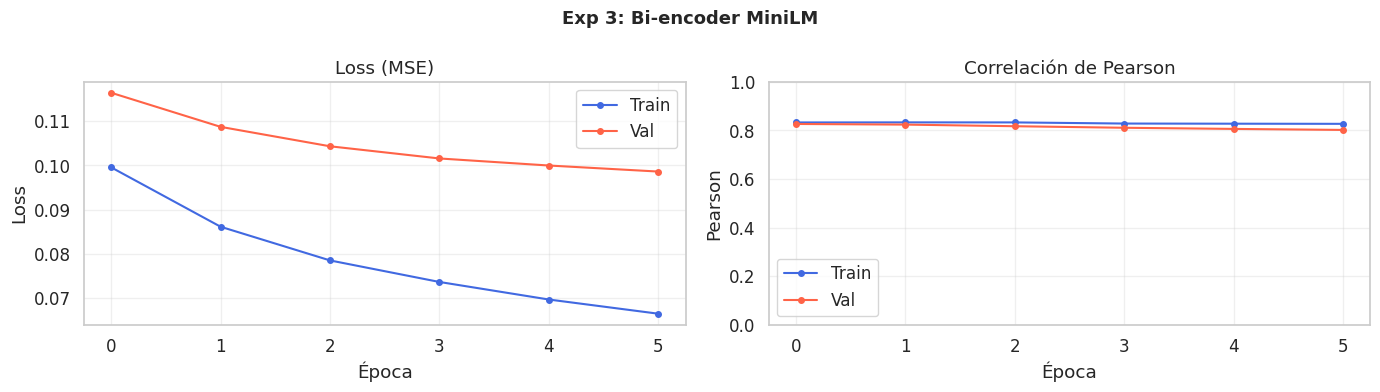

In [ ]:
plot_training_history(
    log_dir=f'{EXP3_DIR}/logs/version_0',
    title='Exp 3: Bi-encoder MiniLM'
)

In [ ]:
results_exp3 = trainer_exp3.test(ckpt_path=checkpoint_cb3.best_model_path, datamodule=data_module_exp3)
exp3_pearson_test = results_exp3[0]['test_pearson']

print(f'\n📊 Experimento 3 — Pearson (val): {exp3_val_pearson:.4f}')
print(f'    Experimento 3 — Pearson (test): {exp3_pearson_test:.4f}')

Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │    0.1060544028878212     │
│       test_pearson        │    0.8030602335929871     │
└───────────────────────────┴───────────────────────────┘


📊 Experimento 3 — Pearson (val): 0.8262
    Experimento 3 — Pearson (test): 0.8031


## Experimento 4: Cross-encoder con LoRa

Este experimento utiliza la misma arquitectura que el experimento 1 (cross-encoder con `roberta-base`), cambiando únicamente el método de fine-tuning. En lugar de actualizar directamente algunas capas, se emplea **LoRA**, que mantiene congelados todos los pesos del modelo e introduce pequeños módulos entrenables en las capas de atención.

La idea es que adaptar el modelo a la tarea no requiere modificar todos sus parámetros, sino solo pequeños ajustes. Por ello LoRA aprende matrices de bajo tamaño que aproximan estos cambios, reduciendo drásticamente el número de parámetros entrenables: de ~14.8M en el experimento 1 a menos de 300K.

LoRA se aplica sobre las matrices de **query** y **value** de cada capa de atención de `roberta-base`, que son los módulos donde la adaptación a la tarea tiene mayor impacto. Los pesos originales permanecen intactos durante todo el entrenamiento, lo que además actúa como regularizador implícito al limitar cuánto puede alejarse el modelo de sus representaciones pre-entrenadas.

Se introduce una nueva clase `STSRegressorLoRA` que es prácticamente idéntica a
`STSRegressorCrossEncoder`. La única diferencia es que al cargar el modleo pre-entrenado se  aplica `get_peft_model(base_model, lora_config)`, que congela todos los pesos originales e inyecta los módulos LoRA en las capas de atención. El resto de la implementación (pooling, cabeza de regresión, función de pérdida y métricas) permanece exactamente igual.

In [ ]:
# Experimento 4  Cross-encoder con LoRA
class STSRegressorLoRA(pl.LightningModule):
    """
    Cross-encoder idéntico al exp 1 pero con LoRA en lugar de full fine-tuning.
    """
    def __init__(self, model_name, lora_config, optimizer_params, pooling='mean'):
        super().__init__()

        # Cargamos el modelo base
        base_model = AutoModel.from_pretrained(model_name)

        # Aplicamos LoRA sobre el modelo
        self.model = get_peft_model(base_model, lora_config)
        self.model.print_trainable_parameters()  # Para ver la reducción de parámetros

        self.regressor = nn.Sequential(
            nn.Dropout(0.1),
            nn.Linear(self.model.config.hidden_size, 1),
        )

        assert pooling in ['cls', 'mean']
        self.pooling = pooling
        self.optimizer_params = optimizer_params
        self.loss_fn = nn.MSELoss()
        self.pearson = PearsonCorrCoef()

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        outputs = self.model(
            input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        )
        last_hidden = outputs.last_hidden_state

        if self.pooling == 'cls':
            pooled = last_hidden[:, 0, :]
        else:
            mask = attention_mask.float()
            mean_coeffs = mask / mask.sum(dim=1, keepdim=True)
            pooled = torch.einsum('bld,bl->bd', last_hidden, mean_coeffs)

        score = self.regressor(pooled).squeeze(-1)
        return torch.sigmoid(score)

    def _step(self, batch):
        encoded, labels = batch
        preds = self(
            encoded['input_ids'],
            encoded['attention_mask'],
            encoded.get('token_type_ids'),
        )
        loss = self.loss_fn(preds, labels)
        pearson = self.pearson(preds, labels)
        return loss, pearson

    def training_step(self, batch, batch_idx):
        loss, pearson = self._step(batch)
        self.log('train_loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('train_pearson', pearson, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, pearson = self._step(batch)
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_pearson', pearson, prog_bar=True)

    def test_step(self, batch, batch_idx):
        loss, pearson = self._step(batch)
        self.log('test_loss', loss)
        self.log('test_pearson', pearson)

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), **self.optimizer_params)

Los hiperparámetros generales (`MAX_LENGTH`, `BATCH_SIZE`, `POOLING`, `lr`) son idénticos al experimento 1. Los hiperparámetros específicos de LoRA son:

- **`r = 8`**: rango de las matrices de bajo tamaño que se añaden al modelo. Controla la capacidad de adaptación de LoRA, valores más altos permiten aproximar cambios más complejos pero aumentan el número de parámetros entrenables. `r=8` es un valor estándar que ofrece un buen equilibrio entre capacidad y eficiencia.

- **`lora_alpha = 16`**: escala que controla la magnitud de las actualizaciones de LoRA. Siguiendo la convención habitual se establece como el doble del rango (`alpha = 2 * r`), lo que garantiza que las actualizaciones tengan una escala adecuada.

- **`target_modules = ['query', 'value']`**: indica en qué módulos de las capas de atención se inyectan las matrices de LoRA. Se aplica sobre query y value por ser los módulos donde la adaptación a la tarea tiene mayor impacto en el rendimiento.

- **`lora_dropout = 0.1`**: dropout aplicado dentro de los módulos LoRA como regularización adicional.

In [ ]:
# Hiperparámetros experimento 4
MODEL_EXP4 = 'FacebookAI/roberta-base'
MAX_LENGTH    = 128
BATCH_SIZE    = 32
POOLING       = 'mean'
OPTIMIZER_PARAMS = {'lr': 2e-5, 'weight_decay': 0.01}
MAX_EPOCHS    = 50

# Configuración de LoRA
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=['query', 'value'],
    lora_dropout=0.1,
    bias='none',
)

# Reutilizamos el mismo DataModule que el exp 1 (cross-encoder)
data_module_exp4 = STSDataModule(MODEL_EXP4, MAX_LENGTH, BATCH_SIZE)
model_exp4 = STSRegressorLoRA(
    MODEL_EXP4,
    lora_config,
    OPTIMIZER_PARAMS,
    pooling=POOLING,
)

data_module_exp4.setup()

Some weights of RobertaModel were not initialized from the model checkpoint at FacebookAI/roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 294,912 || all params: 124,940,544 || trainable%: 0.2360


In [ ]:
# Entrenamiento experimento 4
EXP4_DIR = EXP_DIRS['4_lora']

checkpoint_cb4 = ModelCheckpoint(
    dirpath=f'{EXP4_DIR}',
    monitor='val_pearson',
    mode='max',
    save_top_k=1,
    filename='best-{epoch:02d}-{val_pearson:.4f}',
)
early_stop_cb4 = EarlyStopping(monitor='val_pearson', mode='max', patience=3)

logger_exp4 = CSVLogger(
    save_dir=f'{EXP4_DIR}/logs',
    name='',
)

trainer_exp4 = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator='gpu',
    devices=1,
    precision='16-mixed',
    callbacks=[checkpoint_cb4, early_stop_cb4],
    logger=logger_exp4,
)

trainer_exp4.fit(model_exp4, data_module_exp4)
exp4_val_pearson = checkpoint_cb4.best_model_score.item()
print(f'✅ Checkpoint guardado en: {checkpoint_cb4.best_model_path}')
print(f'✅ Logs guardados en:       {EXP4_DIR}/logs/')

INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/plugins/precision/amp.py:54: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name      | Type            | Params
----------------------------------------------
0 | model     | PeftModel       | 124 M 
1 | regressor | Sequential      | 769   
2 | loss_fn   | MSELoss         | 0     
3 | pearson   | PearsonCorrCoef | 0     
-------

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

✅ Checkpoint guardado en: /content/drive/MyDrive/Master/10. Deep Learning para NLP/00. Proyecto - NLP/Checkpoints/4_lora/checkpoints/best-epoch=27-val_pearson=0.8629.ckpt
✅ Logs guardados en:       /content/drive/MyDrive/Master/10. Deep Learning para NLP/00. Proyecto - NLP/Checkpoints/4_lora/logs/


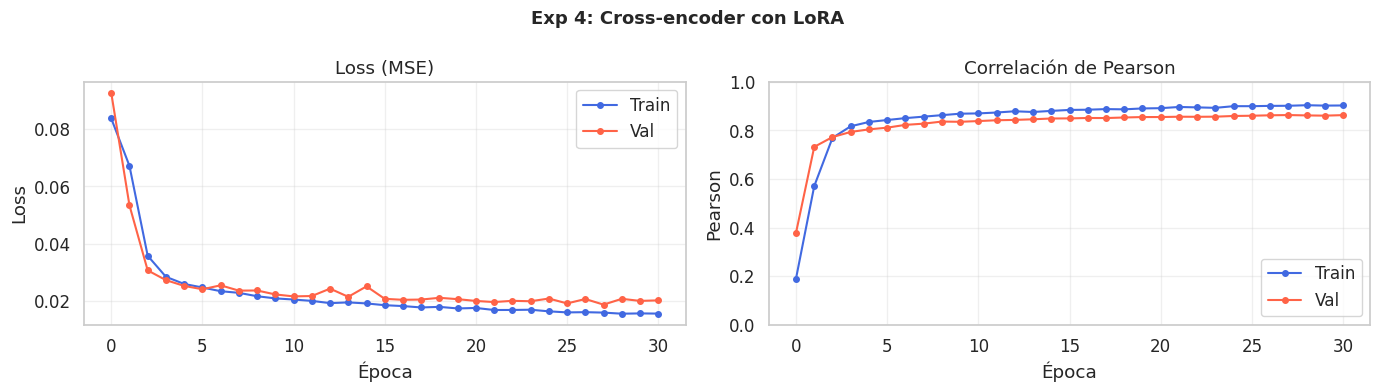

In [ ]:
plot_training_history(
    log_dir=f'{EXP4_DIR}/logs/version_0',
    title='Exp 4: Cross-encoder con LoRA '
)

El modelo obtiene una correlación de Pearson de **0.8671** en test, siendo el mejor resultado de todos los experimentos y superando tanto al baseline (0.8274) como al experimento 1 con full fine-tuning (0.8575), con menos del 0.3% de los parámetros entrenables.

Las curvas de aprendizaje muestran un comportamiento diferente al del experimento 1. El loss de train y validación descienden de forma conjunta y paralela a lo largo de todas las épocas, sin que se observe la brecha característica del overfitting. El Pearson de train y validación también evolucionan de forma muy similar, alcanzando valores de cercanos a 0.92 y 0.86
respectivamente tras 30 épocas. Esto confirma que LoRA actúa como **regularizador implícito**: al limitar las actualizaciones a un espacio de bajo rango, el modelo no puede memorizar el conjunto de entrenamiento con la misma facilidad que en el full fine-tuning.

Este resultado responde directamente a la idea planteada al principio del experimento, LoRA no solo iguala al full fine-tuning sino que lo supera ligeramente, siendo además mucho más eficiente en términos de parámetros entrenables. La reducción del overfitting que se observa en las curvas es la causa directa de esta mejora, ya que el modelo generaliza mejor al conjunto de  test.

In [ ]:
results_exp4 = trainer_exp4.test(ckpt_path=checkpoint_cb4.best_model_path, datamodule=data_module_exp4)
exp4_pearson_test = results_exp4[0]['test_pearson']

print(f'\n📊 Experimento 4 — Pearson (val): {exp4_val_pearson:.4f}')
print(f'   Experimento 4 — Pearson (test): {exp4_pearson_test:.4f}')

Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │    0.02250339463353157    │
│       test_pearson        │    0.8671402335166931     │
└───────────────────────────┴───────────────────────────┘


📊 Experimento 4 — Pearson (val): 0.8629
   Experimento 4 — Pearson (test): 0.8671


## Experimento 5: Bi-encoder con LoRA (MiniLM)
Este experimento combina las dos decisiones que mejores resultados han dado en los experimentos anteriores: el modelo especializado `all-MiniLM-L6-v2` del experimento 3 y el método de fine-tuning con LoRA del experimento 4. La arquitectura es la del bi-encoder, aplicando LoRA en lugar de frozen layers como estrategia de adaptación.

Evaluaremos si puede LoRA preservar mejor el conocimiento pre-entrenado de `all-MiniLM-L6-v2` que el congelado manual de capas. En el experimento 3 se
observó que cualquier actualización de pesos sobre este modelo tendía a empeorar su rendimiento, ya que el dataset no proporciona suficiente señal para mejorar lo que el modelo ya sabe. La hipótesis es que LoRA, al restringir las actualizaciones a un espacio de bajo rango, introduce menos perturbación en las representaciones pre-entrenadas que el fine-tuning convencional.


Se introduce la clase **`STSBiEncoderLoRA`**, que combina el esquema de `STSBiEncoder` con la aplicación de LoRA mediante `get_peft_model`. Al igual que en el experimento 4, todos los pesos originales del modelo quedan congelados y únicamente se actualizan los módulos LoRA inyectados en las capas de atención. El resto de la implementación (método `encode`, cálculo
de la similitud coseno, `MSELoss` y `PearsonCorrCoef`) es idéntico al `STSBiEncoder`, reutilizando además el mismo `STSBiEncoderDataModule` y `STSBiEncoderCollateFn`.

In [ ]:
# Experimento 5 Bi-encoder con LoRA (MiniLM)
class STSBiEncoderLoRA(pl.LightningModule):
    """
    Bi-encoder idéntico al Exp 2/3 pero con LoRA en lugar de frozen layers.
    """
    def __init__(self, model_name, lora_config, optimizer_params, pooling='mean'):
        super().__init__()

        backbone = AutoModel.from_pretrained(model_name)
        self.model = get_peft_model(backbone, lora_config)
        self.model.print_trainable_parameters()

        assert pooling in ['cls', 'mean']
        self.pooling = pooling
        self.optimizer_params = optimizer_params
        self.loss_fn = nn.MSELoss()
        self.pearson = PearsonCorrCoef()

    def encode(self, input_ids, attention_mask, token_type_ids=None):
        outputs = self.model(
            input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        )
        last_hidden = outputs.last_hidden_state

        if self.pooling == 'cls':
            return last_hidden[:, 0, :]
        else:
            mask = attention_mask.float()
            mean_coeffs = mask / mask.sum(dim=1, keepdim=True)
            return torch.einsum('bld,bl->bd', last_hidden, mean_coeffs)

    def forward(self, enc1, enc2):
        emb1 = self.encode(enc1['input_ids'], enc1['attention_mask'], enc1.get('token_type_ids'))
        emb2 = self.encode(enc2['input_ids'], enc2['attention_mask'], enc2.get('token_type_ids'))
        return emb1, emb2

    def _step(self, batch):
        enc1, enc2, labels = batch
        emb1, emb2 = self(enc1, enc2)

        cos_sim = F.cosine_similarity(emb1, emb2)  # [-1, 1]
        preds   = (cos_sim + 1) / 2                 # [0, 1]
        loss    = self.loss_fn(preds, labels)
        pearson = self.pearson(preds, labels)
        return loss, pearson

    def training_step(self, batch, batch_idx):
        loss, pearson = self._step(batch)
        self.log('train_loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('train_pearson', pearson, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, pearson = self._step(batch)
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_pearson', pearson, prog_bar=True)

    def test_step(self, batch, batch_idx):
        loss, pearson = self._step(batch)
        self.log('test_loss', loss)
        self.log('test_pearson', pearson)

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), **self.optimizer_params)

La configuración de LoRA es idéntica a la del Exp. 4 (`r=8`, `lora_alpha=16`,
`target_modules=['query', 'value']`, `lora_dropout=0.1`).Unicmanete se cambia el modelo base:

- **`MODEL_EXP5 = 'sentence-transformers/all-MiniLM-L6-v2'`**: se utiliza el mismo modelo que en el experimento 3, especializado en similitud semántica.

In [ ]:
# Hiperparámetros experimento 5
MODEL_EXP5 = 'sentence-transformers/all-MiniLM-L6-v2'
MAX_LENGTH    = 128
BATCH_SIZE    = 32
POOLING       = 'mean'
OPTIMIZER_PARAMS = {'lr': 2e-5, 'weight_decay': 0.01}
MAX_EPOCHS    = 50

lora_config_exp5 = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=['query', 'value'],
    lora_dropout=0.1,
    bias='none',
)

data_module_exp5 = STSBiEncoderDataModule(MODEL_EXP5, MAX_LENGTH, BATCH_SIZE)
model_exp5 = STSBiEncoderLoRA(
    MODEL_EXP5,
    lora_config_exp5,
    OPTIMIZER_PARAMS,
    pooling=POOLING,
)

data_module_exp5.setup()

trainable params: 73,728 || all params: 22,786,944 || trainable%: 0.3236


In [ ]:
# Entrenamiento experimento 5
EXP5_DIR = EXP_DIRS['5_lora_minilm']

checkpoint_cb5 = ModelCheckpoint(
    dirpath=f'{EXP5_DIR}',
    monitor='val_pearson',
    mode='max',
    save_top_k=1,
    filename='best-{epoch:02d}-{val_pearson:.4f}',
)
early_stop_cb5 = EarlyStopping(monitor='val_pearson', mode='max', patience=5)

logger_exp5 = CSVLogger(
    save_dir=f'{EXP5_DIR}/logs',
    name='',
)

trainer_exp5 = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator='gpu',
    devices=1,
    precision='16-mixed',
    callbacks=[checkpoint_cb5, early_stop_cb5],
    logger=logger_exp5,
)

trainer_exp5.fit(model_exp5, data_module_exp5)
exp5_val_pearson = checkpoint_cb5.best_model_score.item()
print(f'✅ Checkpoint guardado en: {checkpoint_cb5.best_model_path}')
print(f'✅ Logs guardados en:       {EXP5_DIR}/logs/')

INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/plugins/precision/amp.py:54: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:630: Checkpoint directory /content/drive/MyDrive/Master/10. Deep Learning para NLP/00. Proyecto - NLP/Checkpoints/5_lora_minilm/checkpoints exists and is not empty.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Na

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

✅ Checkpoint guardado en: /content/drive/MyDrive/Master/10. Deep Learning para NLP/00. Proyecto - NLP/Checkpoints/5_lora_minilm/checkpoints/best-epoch=00-val_pearson=0.8198.ckpt
✅ Logs guardados en:       /content/drive/MyDrive/Master/10. Deep Learning para NLP/00. Proyecto - NLP/Checkpoints/5_lora_minilm/logs/


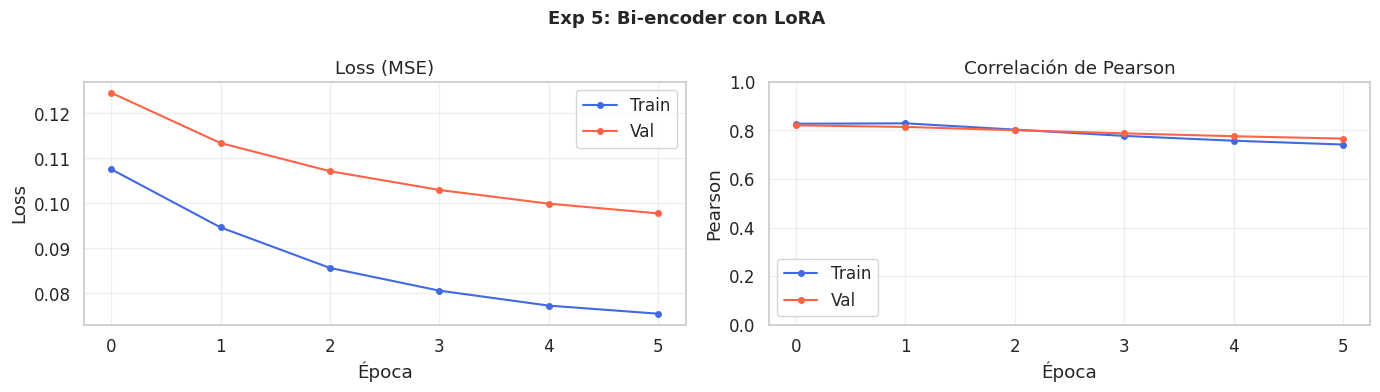

In [ ]:
plot_training_history(
    log_dir=f'{EXP5_DIR}/logs/version_0',
    title='Exp 5: Bi-encoder con LoRA '
)

El modelo obtiene una correlación de Pearson de **0.8001** en test, resultado muy similar al experimento 3 (0.8031) y que tampoco consigue superar al baseline (0.8274). La hipótesis de que LoRA preservaría mejor el conocimiento pre-entrenado que el congelado manual de capas no se confirma: ambos métodos obtienen prácticamente el mismo rendimiento sobre este backbone.

Las curvas de aprendizaje muestran el mismo patrón que en el experimento 3: el Pearson de train y validación arrancan en torno a 0.82 y decaen ligeramente a lo largo de las épocas, sin que el modelo consiga mejorar su punto de partida. El loss de train desciende de forma continua mientras que la de validación se estanca, señal de que el modelo está ajustándose al conjunto de entrenamiento sin transferir esa mejora a datos no vistos.

Este resultado, junto con el del experimento 3, lleva a una conclusión clara: con 5.749 ejemplos de entrenamiento, ningún método de fine-tuning (ni frozen layers ni LoRA) es capaz de mejorar un modelo ya especializado en similitud semántica. El dataset simplemente no proporciona suficiente información nueva respecto a lo que el modelo ya aprendió durante su pre-entrenamiento con más de mil millones de pares de frases.

In [ ]:
results_exp5 = trainer_exp5.test(ckpt_path=checkpoint_cb5.best_model_path, datamodule=data_module_exp5)
exp5_pearson_test = results_exp5[0]['test_pearson']

print(f'\n📊 Experimento 5 — Pearson (val): {exp5_val_pearson:.4f}')
print(f'   Experimento 5 — Pearson (test): {exp5_pearson_test:.4f}')

Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │    0.11588998883962631    │
│       test_pearson        │    0.8008422255516052     │
└───────────────────────────┴───────────────────────────┘


📊 Experimento 5 — Pearson (val): 0.8205
   Experimento 5 — Pearson (test): 0.8008


## Tabla de resultados

Los experimentos se pueden analizar en torno a las tres líneas de comparación planteadas al inicio.

**Arquitectura: cross-encoder vs bi-encoder**

La arquitectura es el factor que más influye en el rendimiento. Los cross-encoders (experimento 1 y 4) superan a todos los bi-encoders fine-tuneados, independientemente del modelo pre-entrenado o el método de fine-tuning empleado. La capacidad del cross-encoder de procesar ambas frases de forma conjunta le proporciona una señal de aprendizaje más directa y rica
para la tarea de regresión, lo que se traduce en una ventaja de hasta 0.17 puntos de Pearson sobre el mejor bi-encoder fine-tuneado.

**Método de fine-tuning: frozen layers vs LoRA**

Dentro de la arquitectura cross-encoder, LoRA (experimento 4) supera al full fine-tuning con frozen layers (experimento 1) en 0.01 unidades de Pearson, usando menos del 0.3% de los parámetros entrenables. Las curvas de aprendizaje explican esta mejora: LoRA reduce el overfitting al restringir las actualizaciones a un espacio de bajo rango, lo que se traduce en una mejor
generalización. En el bi-encoder, sin embargo, ninguno de los dos métodos consigue superar al baseline, por lo que la elección del método de fine-tuning resulta irrelevante cuando el problema de fondo es la limitación del dataset.

**Modelo pre-entrenado: roberta-base vs all-MiniLM-L6-v2**

El impacto del modelo pre-entrenado es determinante en el bi-encoder. Pasar de `roberta-base` (experimento 2, 0.6923) a `all-MiniLM-L6-v2` (experimento 3, 0.8031) supone una mejora de 0.11 nidades sin cambiar ningún otro componente del experimento. Esto confirma que el bi-encoder depende críticamente de la calidad del espacio de embeddings del modelo base, ya que no dispone de atención cruzada para compensar unas representaciones poco calibradas para la tarea.

Sin embargo, el dato más llamativo es que ningún bi-encoder fine-tuneado consigue superar al baseline (0.8274), que no realiza ningún entrenamiento. Esto demuestra que 5.749 ejemplosno son suficientes para mejorar un modelo ya especializado en similitud semántica con más de
mil millones de pares, y que cualquier actualización de pesos introduce más ruido que señal
útil.

In [ ]:
resultados = {
    'Experimento': [
        'Exp 0 - Baseline (Bi-encoder sin fine-tuning)',
        'Exp 1 - Cross-encoder (RoBERTa + regresión)',
        'Exp 2 - Bi-encoder fine-tuned (SBERT)',
        'Exp 3 - Bi-encoder fine-tuned (MiniLM)',
        'Exp 4 - Cross-encoder (RoBERTa + LoRA)',
        'Exp 5 - Bi-encoder (MiniLM + LoRA)',
    ],
    'Modelo': [
        'all-MiniLM-L6-v2',
        'roberta-base',
        'roberta-base',
        'all-MiniLM-L6-v2',
        'roberta-base',
        'all-MiniLM-L6-v2',
    ],
    'Estrategia': [
        'Cosine similarity directo',
        'Par concatenado + MSELoss',
        'Embeddings independientes + MSELoss',
        'Embeddings independientes + MSELoss',
        'Par concatenado + MSELoss + LoRA',
        'Embeddings independientes + MSELoss + LoRA',
    ],
    'Pearson (val)': [
        '-',
        round(exp1_val_pearson, 4),
        round(exp2_val_pearson, 4),
        round(exp3_val_pearson, 4),
        round(exp4_val_pearson, 4),
        round(exp5_val_pearson, 4),
    ],
    'Pearson (test)': [
        round(baseline_pearson_test, 4),
        round(exp1_pearson_test, 4),
        round(exp2_pearson_test, 4),
        round(exp3_pearson_test, 4),
        round(exp4_pearson_test, 4),
        round(exp5_pearson_test, 4),
    ]
}

df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values('Pearson (test)', ascending=False)

print('TABLA DE RESULTADOS — Correlación de Pearson\n')
display(df_resultados)

TABLA DE RESULTADOS — Correlación de Pearson



,Experimento,Modelo,Estrategia,Pearson (val),Pearson (test)
4,Exp 4 - Cross-encoder (RoBERTa + LoRA),roberta-base,Par concatenado + MSELoss + LoRA,0.8629,0.8671
1,Exp 1 - Cross-encoder (RoBERTa + regresión),roberta-base,Par concatenado + MSELoss,0.8532,0.8575
0,Exp 0 - Baseline (Bi-encoder sin fine-tuning),all-MiniLM-L6-v2,Cosine similarity directo,-,0.8274
3,Exp 3 - Bi-encoder fine-tuned (MiniLM),all-MiniLM-L6-v2,Embeddings independientes + MSELoss,0.8262,0.8031
5,Exp 5 - Bi-encoder (MiniLM + LoRA),all-MiniLM-L6-v2,Embeddings independientes + MSELoss + LoRA,0.8205,0.8008
2,Exp 2 - Bi-encoder fine-tuned (SBERT),roberta-base,Embeddings independientes + MSELoss,0.7154,0.6923


El modelo que mejores resultados obtiene es el del  experimento 4** Cross-encoder con LoRA**, con una correlación de Pearson de **0.8671** en test. Destaca no solo por ser el más preciso sino también por ser el más eficiente, logrando superar al full fine-tuning con menos del 0.3% de los parámetros
entrenables.

## Predicción

Los 6 pares de frases empleados en la demostración se extraen del dataset **STS 2016** (`mteb/sts16-sts`), un dataset externo al STS Benchmark utilizado durante el entrenamiento. De esta forma se garantiza que ninguno de los pares ha sido visto por los modelos en ninguna fase del proceso, ni en entrenamiento, ni en validación, ni en test. Al igual que el STS Benchmark, este dataset comparte el mismo formato y escala de anotación (0-5), lo que permite una comparación directa con los scores predichos. Se selecciona un ejemplo representativo por cada nivel de similitud, cubriendo toda la escala de forma uniforme.


In [ ]:
# Cargamos STS16 como fuente de ejemplos de demostración externos
sts16 = load_dataset('mteb/sts16-sts')

# Buscamos un ejemplo representativo por cada nivel de similitud
rangos = [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (4.8, 5.1)]
etiquetas = ['~0', '~1', '~2', '~3', '~4', '~5']

demo_examples = []
for (low, high) in rangos:
    for ex in sts16['test']:
        if low <= ex['score'] < high:
            demo_examples.append({
                'sentence1':      ex['sentence1'],
                'sentence2':      ex['sentence2'],
                'score_esperado': round(ex['score'], 2),
            })
            break

print('Ejemplos seleccionados:')
for ex in demo_examples:
    print(f"  [{ex['score_esperado']}] {ex['sentence1']} | {ex['sentence2']}")

Extracting data files:   0%|          | 0/1 [00:00<?, ?it/s]

Generating test split: 0 examples [00:00, ? examples/s]

Ejemplos seleccionados:
  [0.0] there 's also what the string is made of . | there is also a youtube-version of the film .
  [1.0] you should do it . | you can do it , too .
  [2.0] i did this one time as well . | i have this habit as well .
  [3.0] i remained under the banyan tree , exhausted by my daily ritual of dragooning the men every two hours . | i remained under the banyan tree , exhausted by my daily ritual of herding the cats every two hours .
  [4.0] you have to decide what you want to get out of this . | you have to know what you want to do .
  [5.0] you do not need to worry . | you don 't have to worry .


Se implementan tres funciones de predicción (una por tipo de arquitectura) que reciben el modelo, el tokenizador y las dos frases del par, y devuelven el score de similitud predicho en la escala original [0, 5]:

**`predict_cross_encoder`**: tokeniza el par de frases concatenado, realiza la inferencia con el modelo y desnormaliza la salida de [0, 1] a [0, 5] mediante `denormalize_score`.

**`predict_biencoder`**: tokeniza cada frase de forma independiente, obtiene los embeddings de ambas mediante el método `encode` del modelo, calcula la similitud coseno y la reescala a [0, 5].

**`predict_baseline`**: utiliza directamente el método `encode` de `SentenceTransformer` para obtener los embeddings y calcula la similitud coseno reescalada a [0, 5], sin necesidad de tokenizador explícito.

In [ ]:
# Funciones de predicción por tipo de modelo
def predict_cross_encoder(model, tokenizer, s1, s2):
    """Predicción para STSRegressorCrossEncoder y STSRegressorLoRA."""
    model.eval()
    encoded = tokenizer(
        [(s1, s2)],
        max_length=MAX_LENGTH,
        padding=True,
        truncation=True,
        return_tensors='pt',
    ).to(device)
    with torch.no_grad():
        pred = model(
            encoded['input_ids'],
            encoded['attention_mask'],
            encoded.get('token_type_ids'),
        )
    return denormalize_score(pred.item())  # [0,1] → [0,5]


def predict_biencoder(model, tokenizer, s1, s2):
    """Predicción para STSBiEncoder y STSBiEncoderLoRA."""
    model.eval()
    enc1 = tokenizer(
        [s1], max_length=MAX_LENGTH, padding=True,
        truncation=True, return_tensors='pt',
    ).to(device)
    enc2 = tokenizer(
        [s2], max_length=MAX_LENGTH, padding=True,
        truncation=True, return_tensors='pt',
    ).to(device)
    with torch.no_grad():
        emb1 = model.encode(enc1['input_ids'], enc1['attention_mask'])
        emb2 = model.encode(enc2['input_ids'], enc2['attention_mask'])
    cos_sim = F.cosine_similarity(emb1, emb2).item()
    pred_norm = (cos_sim + 1) / 2   # [-1,1] → [0,1]
    return denormalize_score(pred_norm)  # [0,1] → [0,5]


def predict_baseline(model, s1, s2):
    """Predicción para el baseline SentenceTransformer."""
    emb1 = model.encode([s1], convert_to_tensor=True)
    emb2 = model.encode([s2], convert_to_tensor=True)
    cos_sim = F.cosine_similarity(emb1, emb2).item()
    return ((cos_sim + 1) / 2) * 5  # [-1,1] → [0,5]

Dado que la demostración se ejecuta de forma independiente al entrenamiento, los modelos se cargan directamente desde los checkpoints guardados. La función `get_best_checkpoint` localiza automáticamente el fichero `.ckpt` en la carpeta de cada experimento, aprovechando que `save_top_k=1` garantiza que solo existe un checkpoint por experimento correspondiente al mejor valor de `val_pearson` obtenido durante el entrenamiento.

Cada modelo se instancia mediante `load_from_checkpoint`, que restaura tanto la arquitectura como los pesos guardados, y se mueve a GPU con `.to(device)`. Se carga también el tokenizador correspondiente a cada modelo pre-entrenado, necesario para las funciones de predicción.

In [ ]:
# Carga de modelos desde checkpoints
def get_best_checkpoint(exp_dir):
    """Busca el único checkpoint guardado en la carpeta de checkpoints."""
    ckpts = glob.glob(f'{exp_dir}/*.ckpt')
    assert len(ckpts) > 0, f'No se encontró ningún checkpoint en {exp_dir}/'
    # save_top_k=1 garantiza que solo hay uno, pero por si acaso ordenamos por val_pearson
    # que está en el nombre del fichero: best-epoch=XX-val_pearson=X.XXXX.ckpt
    ckpts.sort(reverse=True)
    print(f'  Checkpoint encontrado: {ckpts[0]}')
    return ckpts[0]

# Rutas al mejor checkpoint de cada experimento
ckpt_exp1 = get_best_checkpoint(EXP_DIRS['1_crossencoder'])
ckpt_exp2 = get_best_checkpoint(EXP_DIRS['2_biencoder'])
ckpt_exp3 = get_best_checkpoint(EXP_DIRS['3_biencoder_minilm'])
ckpt_exp4 = get_best_checkpoint(EXP_DIRS['4_lora'])
ckpt_exp5 = get_best_checkpoint(EXP_DIRS['5_lora_minilm'])

# Exp 1
model_demo_exp1 = STSRegressorCrossEncoder.load_from_checkpoint(
    ckpt_exp1,
    model_name=MODEL_EXP1,
    optimizer_params=OPTIMIZER_PARAMS,
    pooling=POOLING,
    frozen_layers=FROZEN_LAYERS,
).to(device)
tokenizer_exp1 = AutoTokenizer.from_pretrained(MODEL_EXP1)

# Exp 2
model_demo_exp2 = STSBiEncoder.load_from_checkpoint(
    ckpt_exp2,
    model_name=MODEL_EXP2,
    optimizer_params=OPTIMIZER_PARAMS,
    pooling='mean',
    frozen_layers=6,
).to(device)
tokenizer_exp2 = AutoTokenizer.from_pretrained(MODEL_EXP2)

# Exp 3
model_demo_exp3 = STSBiEncoder.load_from_checkpoint(
    ckpt_exp3,
    model_name=MODEL_EXP3,
    optimizer_params=OPTIMIZER_PARAMS_EXP3,
    pooling='mean',
    frozen_layers=FROZEN_LAYERS_EXP3,
).to(device)
tokenizer_exp3 = AutoTokenizer.from_pretrained(MODEL_EXP3)

# Exp 4
model_demo_exp4 = STSRegressorLoRA.load_from_checkpoint(
    ckpt_exp4,
    model_name=MODEL_EXP4,
    lora_config=lora_config,
    optimizer_params=OPTIMIZER_PARAMS,
    pooling='mean',
).to(device)
tokenizer_exp4 = AutoTokenizer.from_pretrained(MODEL_EXP4)

# Exp 5
model_demo_exp5 = STSBiEncoderLoRA.load_from_checkpoint(
    ckpt_exp5,
    model_name=MODEL_EXP5,
    lora_config=lora_config_exp5,
    optimizer_params=OPTIMIZER_PARAMS,
    pooling='mean',
).to(device)
tokenizer_exp5 = AutoTokenizer.from_pretrained(MODEL_EXP5)

print('Todos los modelos cargados.')

  Checkpoint encontrado: /content/drive/MyDrive/Master/10. Deep Learning para NLP/00. Proyecto - NLP/Checkpoints/1_Crossencoder/best-epoch=05-val_pearson=0.8532.ckpt
  Checkpoint encontrado: /content/drive/MyDrive/Master/10. Deep Learning para NLP/00. Proyecto - NLP/Checkpoints/2_Biencoder/best-epoch=01-val_pearson=0.7154.ckpt
  Checkpoint encontrado: /content/drive/MyDrive/Master/10. Deep Learning para NLP/00. Proyecto - NLP/Checkpoints/3_Biencoder_minilm/best-epoch=00-val_pearson=0.8262.ckpt
  Checkpoint encontrado: /content/drive/MyDrive/Master/10. Deep Learning para NLP/00. Proyecto - NLP/Checkpoints/4_lora/best-epoch=27-val_pearson=0.8629.ckpt
  Checkpoint encontrado: /content/drive/MyDrive/Master/10. Deep Learning para NLP/00. Proyecto - NLP/Checkpoints/5_lora_minilm/best-epoch=00-val_pearson=0.8205.ckpt


Some weights of RobertaModel were not initialized from the model checkpoint at FacebookAI/roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at FacebookAI/roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at FacebookAI/roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 294,912 || all params: 124,940,544 || trainable%: 0.2360
trainable params: 73,728 || all params: 22,786,944 || trainable%: 0.3236
Todos los modelos cargados.


In [ ]:
# Predicciones para los 6 ejemplos
modelos = {
    'Baseline (MiniLM)':       lambda s1, s2: predict_baseline(baseline_model, s1, s2),
    'Exp 1 - Cross FT':        lambda s1, s2: predict_cross_encoder(model_demo_exp1, tokenizer_exp1, s1, s2),
    'Exp 2 - Bi RoBERTa':      lambda s1, s2: predict_biencoder(model_demo_exp2, tokenizer_exp2, s1, s2),
    'Exp 3 - Bi MiniLM FT':    lambda s1, s2: predict_biencoder(model_demo_exp3, tokenizer_exp3, s1, s2),
    'Exp 4 - Cross LoRA':      lambda s1, s2: predict_cross_encoder(model_demo_exp4, tokenizer_exp4, s1, s2),
    'Exp 5 - Bi MiniLM LoRA':  lambda s1, s2: predict_biencoder(model_demo_exp5, tokenizer_exp5, s1, s2),
}

In [ ]:
# Construimos el DataFrame
rows = []
for ex in demo_examples:
    row = {
        'Score esperado': ex['score_esperado'],
        'Frase 1': ex['sentence1'],
        'Frase 2': ex['sentence2'],
    }
    for nombre, fn in modelos.items():
        row[nombre] = round(fn(ex['sentence1'], ex['sentence2']), 3)
    rows.append(row)

df_demo = pd.DataFrame(rows)
display(df_demo)

,Score esperado,Frase 1,Frase 2,Baseline (MiniLM),Exp 1 - Cross FT,Exp 2 - Bi RoBERTa,Exp 3 - Bi MiniLM FT,Exp 4 - Cross LoRA,Exp 5 - Bi MiniLM LoRA
0,0.0,there 's also what the string is made of .,there is also a youtube-version of the film .,2.830,0.638,2.285,2.757,0.942,2.865
1,1.0,you should do it .,"you can do it , too .",3.793,3.676,3.537,3.737,3.497,3.788
2,2.0,i did this one time as well .,i have this habit as well .,3.650,2.565,3.242,3.601,1.539,3.704
3,3.0,"i remained under the banyan tree , exhausted b...","i remained under the banyan tree , exhausted b...",4.656,3.216,4.280,4.685,3.176,4.653
4,4.0,you have to decide what you want to get out of...,you have to know what you want to do .,3.899,3.017,3.216,3.766,3.167,3.919
5,5.0,you do not need to worry .,you don 't have to worry .,4.780,4.771,4.744,4.764,4.749,4.774


La tabla y el gráfico muestran las predicciones de cada modelo para los 6 pares extraídos del STS 2016, comparadas con el score esperado real.

- **Score 0**: el par no tiene ninguna relación semántica y el experimento 1 y experimento 4 (cross-encoders) son los únicos que lo detectan correctamente, prediciendo valores cercanos a 0. El resto de modelos sobreestima notablemente la similitud, asignando scores en torno a 2.8-3.0

- **Scores 1 y 2**: es la zona más difícil para todos los modelos. Los bi-encoders sobreestiman consistentemente, agrupando sus predicciones entre 3.5 y 3.8 para pares con score real de 1 y 2. El experimento 4 es el más preciso en el score 2 (1.539), aunque subestima en el score 1 (3.497).

- **Score 3**: todos los modelos sobreestiman ligeramente, prediciendo valores entre 3.2 y 4.7. Los bi-encoders con MiniLM (experimentos 3 y 5) son los que más se alejan del valor real.

- **Score 4**: todos los modelos subestiman en este caso, prediciendo valores
entre 3.0 y 3.9 para un par con score real de 4.0.

- **Score 5**: es la zona donde todos los modelos convergen y funcionan mejor, prediciendo valores muy cercanos al score real (entre 4.7 y 4.8), lo que confirma que detectar similitud alta es la tarea más sencilla para todas las arquitecturas.

En conjunto, los resultados refuerzan las conclusiones obtenidas durante la evaluación global: Los cross-encoders son más precisos a lo largo de toda la escala, especialmente en la detección de pares con baja similitud semántica, mientras que los bi-encoders tienden a concentrar sus predicciones en la zona media-alta independientemente del score real.

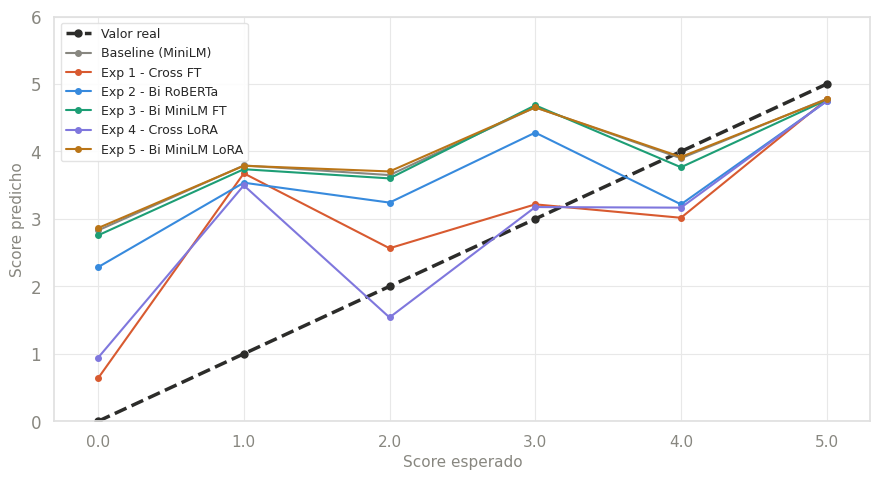

In [ ]:
GT_COL      = "Score esperado"
EXCLUDE_COLS = ["Frase 1", "Frase 2"]

# Colores asignados por orden a los modelos
PALETTE = ["#888780", "#D85A30", "#378ADD",  "#1D9E75", "#7F77DD",   "#BA7517",  ]

# Extraer modelos automáticamente del df
model_cols = [c for c in df_demo.columns if c not in [GT_COL] + EXCLUDE_COLS]
x = df_demo[GT_COL].tolist()

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Ground truth (línea discontinua)
ax.plot(x, x, color="#2C2C2A", linewidth=2.5, linestyle="--",
        marker="o", markersize=5, label="Valor real")

for i, col in enumerate(model_cols):
    color = PALETTE[i % len(PALETTE)]
    ax.plot(x, df_demo[col].tolist(), color=color, linewidth=1.5,
            linestyle="-", marker="o", markersize=4, label=col)

# Ejes y estilo
ax.set_xlim(min(x) - 0.3, max(x) + 0.3)
ax.set_ylim(0, max(x) + 0.5)
ax.set_xticks(x)
ax.set_xticklabels([str(v) for v in x], fontsize=11)
ax.set_yticks(range(0, int(max(x)) + 2))
ax.set_ylabel("Score predicho", fontsize=11, color="#888780")
ax.set_xlabel("Score esperado", fontsize=11, color="#888780")
ax.tick_params(colors="#888780")
for spine in ax.spines.values():
    spine.set_edgecolor("#e0e0e0")
ax.grid(color="#e8e8e8", linewidth=0.8)
ax.set_axisbelow(True)

ax.legend(fontsize=9, frameon=True, framealpha=0.9,
          edgecolor="#e0e0e0", loc="upper left")

plt.tight_layout()
plt.show()